# From a material request to reproducible methods

**A worked example of SBOL provenance, cloning planning, LabOP, and robot compilation.**

Suppose we want **two plated samples of an intended strain**. We have an insert, cells, and reagents, but the vector is available only as a received bacterial stab. Before the downstream liquid handling can be specified, the planner must account for that material form and an external preparation step.

We will author the inputs as Python objects, save and ingest them, resolve the build, and compile the same experiment for an OT-2, Flex, and Hamilton STAR. We will then attach a separate, explicitly synthetic run record and inspect the documents that could accompany a digital methods section.

**This is a software example.** The tiny sequences and arbitrary quantities and method parameters are compiler fixtures, not validated laboratory methods. The notebook compiles code offline and generates synthetic observations; it never connects to a robot or asserts that an experiment occurred.

By the end, we will be able to follow one material and one operation across the Python model, SBOL, LabOP, generated source, and run evidence.


## 1. Open the notebook in the project environment

Use Python 3.11 or 3.12. From the repository root, launch:

```sh
uv run --extra opentrons --extra star --with jupyterlab jupyter lab examples/cloning_provenance.ipynb
```

Choose the Python kernel provided by that environment and run the cells in order. The robot extras supply the target dependencies; Jupyter is a notebook tool rather than a runtime dependency of `lab`.

Each execution creates a fresh directory under the repository's ignored `build/cloning-notebook/` directory. Existing bundles are left intact. Apart from installing the environment, the walkthrough needs no network services or credentials.


In [1]:
import hashlib
import json
from collections import Counter
from dataclasses import replace
from datetime import UTC, datetime, timedelta
from decimal import Decimal
from html import escape
from pathlib import Path
from tempfile import mkdtemp

from IPython.display import HTML, SVG, Code, Markdown, display
from rdflib import RDF, Graph, Namespace, URIRef

import lab
from lab import uL
from lab.execution import Outcome, OutputRecord, Run, RunMode, StepRecord
from lab.experiments import cloning
from lab.experiments.cloning.methods import (
    AssemblyMethod,
    CloningMethods,
    ExternalPreparationMethod,
    PlatingMethod,
    Reagent,
    TransformationMethod,
)
from lab.experiments.cloning.planning import BuildRequest, CountTarget
from lab.experiments.cloning.sequences import CIRCULAR, LINEAR
from lab.experiments.cloning.systems import (
    AssemblyRecipe,
    CloningSystem,
    ExternalPreparationRecipe,
    FragmentSelection,
    PlatingRecipe,
    TransformationRecipe,
)
from lab.inventory import CountedStock, Inventory, MaterialForm, Stock
from lab.operations import Hold
from lab.provenance import (
    Activity,
    Agent,
    Component,
    Document,
    EvidenceState,
    Implementation,
    Sequence,
)
from lab.provenance.vocabulary import DNA, IUPAC_DNA, SMALL_MOLECULE
from lab.targets import LiquidHandler

root = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "src/lab").is_dir() and (candidate / "pyproject.toml").is_file()
)
output_parent = root / "build/cloning-notebook"
output_parent.mkdir(parents=True, exist_ok=True)
output_dir = Path(mkdtemp(prefix="example-", dir=output_parent))
NS = "https://example.org/cloning_notebook"
print("Artifacts:", output_dir.relative_to(root))

Artifacts: build/cloning-notebook/example-mqpz8eqa


In [2]:
def local(identity):
    # Short labels for tables; the underlying objects retain full IRIs.
    return str(identity).removeprefix(NS + "/")


def table(headers, rows):
    # Small, dependency-free HTML tables for notebook inspection.
    head = "".join(f"<th>{escape(str(value))}</th>" for value in headers)
    body = "".join(
        "<tr>" + "".join(f"<td>{escape(str(value))}</td>" for value in row) + "</tr>"
        for row in rows
    )
    display(HTML(f"<table><thead><tr>{head}</tr></thead><tbody>{body}</tbody></table>"))

## 2. Separate the design from a particular material

A `Component` describes a design. A `Sequence` supplies sequence information. An `Implementation` identifies a particular material or planned realization of a design. A `Stock` adds an availability assertion: material form, quantity, and optionally a location.

These are separate identities. Two aliquots of the same design need distinct implementation identities if they are to be counted independently.

First, author the designs. `Document.add()` explicitly registers objects; references do not implicitly register or fetch them. `freeze()` will check the graph and return an immutable snapshot.


In [3]:
document = Document(namespace=NS)

vector_sequence = Sequence(
    identity=document.iri("vector_sequence"),
    elements="AAAAGAATTCTTTT",
    encoding=IUPAC_DNA,
)
insert_sequence = Sequence(
    identity=document.iri("insert_sequence"),
    elements="GGGAATTCCCCGAATTCGG",
    encoding=IUPAC_DNA,
)
vector = Component(
    identity=document.iri("vector"),
    types=(DNA, CIRCULAR),
    sequences=(vector_sequence.ref,),
)
insert = Component(
    identity=document.iri("insert"),
    types=(DNA, LINEAR),
    sequences=(insert_sequence.ref,),
)
construct = Component(identity=document.iri("construct"), types=(DNA, CIRCULAR))
cells = Component(identity=document.iri("cells"), types=(NS + "/cell_type",))
strain = Component(identity=document.iri("strain"), types=(NS + "/cell_type",))
buffer = Component(identity=document.iri("buffer"), types=(SMALL_MOLECULE,))
water = Component(identity=document.iri("water"), types=(SMALL_MOLECULE,))
broth = Component(identity=document.iri("broth"), types=(SMALL_MOLECULE,))
substrate = Component(identity=document.iri("substrate"), types=(SMALL_MOLECULE,))
document.add(
    vector_sequence,
    insert_sequence,
    vector,
    insert,
    construct,
    cells,
    strain,
    buffer,
    water,
    broth,
    substrate,
)
print(f"Authored {len(document.objects)} design and sequence objects.")

Authored 11 design and sequence objects.


The starting inventory contains one **counted** vector stab and several **liquid** stocks. A stab has a count, not an invented pipettable volume. Its `derived_from` reference records the asserted intended design; `built` remains unspecified because this fixture provides no structural verification.

`RECORDED` below models supplied inventory assertions inside our synthetic scenario. It is not a claim about real stock in a laboratory.


In [4]:
received = Implementation(
    identity=document.iri("received_stab"),
    derived_from=(vector.ref,),
    evidence_state=EvidenceState.RECORDED,
)
document.add(received)
stocks = [
    CountedStock(
        identity=document.iri("stab_stock"),
        implementation=received.ref,
        design=vector.ref,
        form=MaterialForm.BACTERIAL_STAB,
        count=1,
    )
]

for design, form, quantity in (
    (insert, MaterialForm.DNA, 10),
    (buffer, MaterialForm.REAGENT, 10),
    (water, MaterialForm.REAGENT, 10),
    (cells, MaterialForm.COMPETENT_CELLS, 20),
    (broth, MaterialForm.REAGENT, 20),
):
    material = Implementation(
        identity=design.identity + "/material",
        derived_from=(design.ref,),
        evidence_state=EvidenceState.RECORDED,
    )
    document.add(material)
    stocks.append(
        Stock(
            identity=design.identity + "/stock",
            implementation=material.ref,
            design=design.ref,
            form=form,
            quantity=Decimal(quantity) * uL,
        )
    )

inventory = Inventory(identity=document.iri("inventory"), stocks=tuple(stocks))
snapshot = document.freeze()
inventory.validate(snapshot)
table(
    ("Design", "Form", "Available", "Quantity kind"),
    [
        (local(s.design.identity), s.form.value, s.amount, "count" if s.form.counted else "µL")
        for s in inventory.stocks
    ],
)

Design,Form,Available,Quantity kind
broth,reagent,20,µL
buffer,reagent,10,µL
cells,competent_cells,20,µL
insert,dna,10,µL
vector,bacterial_stab,1,count
water,reagent,10,µL


## 3. State the available methods and routes

Methods supply explicit quantities and procedural parameters. Recipes supply the permitted relationships between designs and material forms. Keeping both as typed inputs makes the selected procedure inspectable and serializable.

The external preparation method references a supplied procedure and an **expected** output quantity. Its instructions are a fixture placeholder. That output can participate in a prospective plan, but it does not become observed inventory when we compile.

The next two cells reproduce the repository's synthetic method fixture. The numbers are present so every compiler input is visible; they do not prescribe a laboratory method.


In [5]:
preparation_method = ExternalPreparationMethod(
    identity=document.iri("preparation_method"),
    procedure=document.iri("supplied_procedure"),
    instructions="Apply the supplied test procedure and record material and quantity.",
    source_count=1,
    output_volume_ul=Decimal(10),
)
assembly_method = AssemblyMethod(
    identity=document.iri("assembly_method"),
    enzyme="EcoRI",
    dna_volume_ul=Decimal(1),
    reaction_volume_ul=Decimal(5),
    output_volume_ul=Decimal(5),
    reagents=(Reagent(component=buffer.ref, volume_ul=Decimal(1)),),
    diluent=water.ref,
    profile=(Hold(Decimal(25), Decimal(1)),),
    cycles=1,
    mix_volume_ul=Decimal(2),
    mix_cycles=1,
)

In [6]:
transformation_method = TransformationMethod(
    identity=document.iri("transformation_method"),
    cell_volume_ul=Decimal(2),
    dna_volume_ul=Decimal(1),
    recovery=Reagent(component=broth.ref, volume_ul=Decimal(2)),
    profile=(Hold(Decimal(25), Decimal(1)),),
    recovery_profile=(Hold(Decimal(25), Decimal(1)),),
    output_volume_ul=Decimal(5),
    cell_mix_volume_ul=Decimal(1),
    cell_mix_cycles=1,
    dna_mix_cycles=1,
    initial_celsius=Decimal(25),
)
plating_method = PlatingMethod(
    identity=document.iri("plating_method"),
    substrate=substrate.ref,
    diluent=broth.ref,
    transfer_volume_ul=Decimal(1),
    dilution_factors=(Decimal(2), Decimal(3)),
    spot_volume_ul=Decimal(1),
    spot_height_mm=Decimal(2),
    mix_volume_ul=Decimal(1),
    mix_cycles=1,
)
methods = CloningMethods(
    preparations=(preparation_method,),
    assemblies=(assembly_method,),
    transformations=(transformation_method,),
    platings=(plating_method,),
)
table(
    ("Method type", "Identity"),
    [(type(method).__name__, local(method.identity)) for method in methods.all],
)

Method type,Identity
AssemblyMethod,assembly_method
TransformationMethod,transformation_method
PlatingMethod,plating_method
ExternalPreparationMethod,preparation_method


Now define the routes. The preparation explicitly changes `BACTERIAL_STAB` into `DNA`. Assembly explicitly selects fragments; it does not derive assembly ordering from a generic ancestry edge. Transformation names the chassis and plasmid design. Plating consumes culture and produces a counted deposited sample.

The substrate is a supplied consumable precondition recorded in provenance. The planner does not currently reserve physical agar plates or tips from inventory.


In [7]:
system = CloningSystem(
    identity=document.iri("system"),
    recipes=(
        ExternalPreparationRecipe(
            identity=document.iri("preparation_recipe"),
            product=vector.ref,
            source=vector.ref,
            source_form=MaterialForm.BACTERIAL_STAB,
            output_form=MaterialForm.DNA,
            method=preparation_method.identity,
        ),
        AssemblyRecipe(
            identity=document.iri("assembly_recipe"),
            product=construct.ref,
            enzyme="EcoRI",
            fragments=(
                FragmentSelection(component=vector.ref, left_cut=5, right_cut=5),
                FragmentSelection(component=insert.ref, left_cut=3, right_cut=12),
            ),
            method=assembly_method.identity,
        ),
        TransformationRecipe(
            identity=document.iri("transformation_recipe"),
            product=strain.ref,
            chassis=cells.ref,
            plasmids=(construct.ref,),
            method=transformation_method.identity,
        ),
        PlatingRecipe(
            identity=document.iri("plating_recipe"),
            product=strain.ref,
            method=plating_method.identity,
        ),
    ),
)
table(
    ("Recipe type", "Product", "Method"),
    [
        (type(recipe).__name__, local(recipe.product.identity), local(recipe.method))
        for recipe in system.recipes
    ],
)

Recipe type,Product,Method
AssemblyRecipe,construct,assembly_method
PlatingRecipe,strain,plating_method
ExternalPreparationRecipe,vector,preparation_method
TransformationRecipe,strain,transformation_method


## 4. Save the inputs, then ingest them

The Python authoring layer can be replaced by files from another system. We write the SBOL3 document and companion inventory, system, and method files, then read them through the public APIs before planning.

The supported provenance intake is **SBOL3 Turtle**. A BuildCompiler SBOL2 bundle requires an explicit translation adapter. Native pySBOL3 objects are available through `to_sbol3()` as a detached view; they do not own the compiler's mutable state.


In [8]:
input_dir = output_dir / "authored-inputs"
snapshot.write(input_dir / "provenance.ttl")
inventory.write(input_dir / "inventory.json")
system.write(input_dir / "system.json")
methods.write(input_dir / "methods.json")

loaded_document = Document.read(input_dir / "provenance.ttl", namespace=NS).freeze()
loaded_inventory = Inventory.read(input_dir / "inventory.json", document=loaded_document)
loaded_system = CloningSystem.read(input_dir / "system.json")
loaded_methods = CloningMethods.read(input_dir / "methods.json")

assert loaded_document.digest == snapshot.digest
assert loaded_inventory == inventory
assert loaded_system == system
assert loaded_methods == methods
print("All four inputs round-trip without changing their model content.")

All four inputs round-trip without changing their model content.


## 5. Ask for two plated samples

The request specifies a design, material form, and count. The planner resolves available stock and explicit routes, allocates shared material, and returns tasks in dependency order.

`ready` means the model has resolved its required inputs and routes. It does not mean that the external preparation has been performed. Each plated output means one deposited sample, not a verified colony or clone.


In [9]:
request = BuildRequest(
    identity=document.iri("request"),
    targets=(CountTarget(design=strain.ref, count=2, form=MaterialForm.PLATED_SAMPLE),),
)
supplied = dict(
    document=loaded_document,
    inventory=loaded_inventory,
    system=loaded_system,
    methods=loaded_methods,
)
plan = cloning.plan(request, **supplied)
plan.require_ready()
task_numbers = {task.identity: index for index, task in enumerate(plan.tasks, 1)}
table(
    ("Stage", "Task", "Depends on", "Output form", "Expected quantity"),
    [
        (
            index,
            task.kind.value,
            ", ".join(str(task_numbers[dep]) for dep in task.depends_on) or "inventory",
            task.output_form.value,
            f"{task.output_count} count"
            if task.output_form.counted
            else f"{task.output_volume_ul} µL",
        )
        for index, task in enumerate(plan.tasks, 1)
    ],
)
assert len(plan.tasks) == 5
assert sum(product.count for product in plan.products) == 2

Stage,Task,Depends on,Output form,Expected quantity
1,preparation,inventory,dna,10 µL
2,assembly,1,dna,5 µL
3,transformation,2,culture,5 µL
4,plating,3,plated_sample,1 count
5,plating,3,plated_sample,1 count


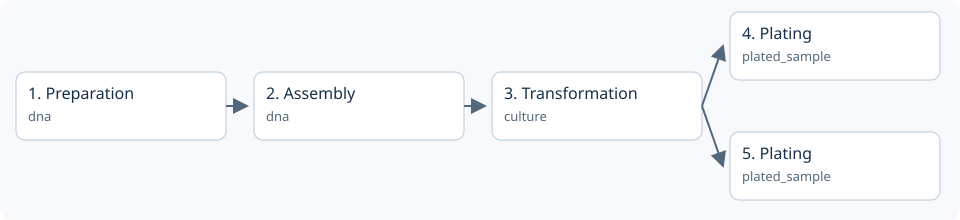

In [10]:
# Draw the resolved material dependency graph without a JavaScript renderer.
positions = [(16, 72), (254, 72), (492, 72), (730, 12), (730, 132)]
parts = [
    '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 960 220" '
    'role="img" aria-label="Preparation, assembly, transformation, then two plating stages">',
    '<rect width="960" height="220" fill="#f7f9fc" rx="12"/>',
    '<defs><marker id="cloning-arrow" markerWidth="8" markerHeight="8" '
    'refX="7" refY="4" orient="auto"><path d="M0,0 L8,4 L0,8" '
    'fill="#53677d"/></marker></defs>',
]
for index, task in enumerate(plan.tasks):
    x, y = positions[index]
    for parent in task.depends_on:
        px, py = positions[task_numbers[parent] - 1]
        parts.append(
            f'<path d="M{px + 210},{py + 34} L{x - 7},{y + 34}" '
            'stroke="#53677d" stroke-width="2" marker-end="url(#cloning-arrow)"/>'
        )
    parts.extend(
        [
            f'<rect x="{x}" y="{y}" width="210" height="68" rx="9" fill="white" stroke="#b7c8da"/>',
            f'<text x="{x + 12}" y="{y + 27}" fill="#162f49" '
            f'font-family="sans-serif" font-size="16">{index + 1}. '
            f"{escape(task.kind.value.title())}</text>",
            f'<text x="{x + 12}" y="{y + 49}" fill="#53677d" '
            f'font-family="sans-serif" font-size="13">{escape(task.output_form.value)}</text>',
        ]
    )
parts.append("</svg>")
display(SVG("".join(parts)))

Both plating tasks depend on the same culture output. The arrows show material dependencies; the generated experiment still has an ordered stage list.

We can also ask what happens when a necessary route is absent. Removing only the preparation recipe leaves the vector stab in inventory, but that cannot satisfy the requirement for vector DNA. Inspect the diagnostic rather than generating a protocol from an unresolved plan.


In [11]:
without_preparation = replace(
    loaded_system,
    recipes=tuple(
        recipe
        for recipe in loaded_system.recipes
        if not isinstance(recipe, ExternalPreparationRecipe)
    ),
)
unresolved = cloning.plan(request, **{**supplied, "system": without_preparation})
assert not unresolved.ready
table(
    ("Requirement", "Design", "Form", "Explanation"),
    [
        (item.kind.value, local(item.design.identity), item.form.value, item.message)
        for item in unresolved.requirements
    ],
)

Requirement,Design,Form,Explanation
preparation,vector,dna,Prepare https://example.org/cloning_notebook/vector as dna; available forms: bacterial_stab


## 6. Inspect the planned SBOL provenance

Planning adds activities and planned implementations to a new provenance snapshot. The original input snapshot is unchanged. Assembly sequence calculation also records its computational provenance; it does not establish that DNA was physically built.

Follow the assembly output to the activity that generates it, the materials that activity uses, and the agent and method associated with it. These correspond directly to the SBOL3/PROV concepts exposed by pySBOL3.


In [12]:
assembly_task = next(task for task in plan.tasks if task.kind.value == "assembly")
planned_material = plan.document.resolve(assembly_task.output)
activity = plan.document.get(assembly_task.identity, Activity)
association = activity.association[0]
table(
    ("Object or relationship", "Value"),
    [
        ("Implementation.identity", local(planned_material.identity)),
        (
            "Implementation.derived_from",
            ", ".join(local(r.identity) for r in planned_material.derived_from),
        ),
        ("Implementation.generated_by", local(planned_material.generated_by[0].identity)),
        ("Implementation.evidence_state", planned_material.evidence_state.name),
        ("Implementation.built", planned_material.built),
        ("Activity.usage", ", ".join(local(u.entity.identity) for u in activity.usage)),
        ("Association.agent", local(association.agent.identity)),
        ("Association.plan", local(association.plan.identity)),
    ],
)
assert planned_material.evidence_state is EvidenceState.PLANNED
assert planned_material.built is None
assert loaded_document.digest == snapshot.digest
native_validation = plan.document.to_sbol3().validate()
assert not native_validation.errors, native_validation.errors
print("Native pySBOL3 validation errors:", len(native_validation.errors))

Object or relationship,Value
Implementation.identity,request/assembly_1_27f98de747bc/output
Implementation.derived_from,assembly_recipe/calculation_09daed6b1242b67c/product
Implementation.generated_by,request/assembly_1_27f98de747bc
Implementation.evidence_state,PLANNED
Implementation.built,None
Activity.usage,"buffer/material, request/preparation_1_592737bb7db3/output, insert/material, water/material"
Association.agent,request/planner
Association.plan,assembly_method


Native pySBOL3 validation errors: 0


## 7. Build the canonical experiment and its handoffs

`cloning.build()` converts the resolved tasks into an `ExperimentPlan`. Each `ProtocolStage` contains a frozen `RecordedProtocol`, logical deck requirements, dependencies, and material handoffs. Protocols contain the one authoritative sequence of operations used by the output writers.

The external preparation is one explicit operation. It consumes the counted source at its step boundary and declares the expected liquid output; the output is not preloaded as existing stock.


In [13]:
experiment = cloning.build(plan)
table(
    ("Stage", "External", "Operations", "Operation types"),
    [
        (
            stage.protocol.name,
            stage.external,
            len(stage.protocol.steps),
            ", ".join(type(step).__name__ for step in stage.protocol.steps),
        )
        for stage in experiment.stages
    ],
)
assert sum(len(stage.protocol.steps) for stage in experiment.stages) == 29
print("Semantic experiment SHA-256:", experiment.digest)

Stage,External,Operations,Operation types
Preparation 1,True,1,ExternalPreparation
Assembly 2,False,6,"Transfer, Transfer, Transfer, Transfer, Mix, Thermocycle"
Transformation 3,False,8,"SetTemperature, Transfer, Mix, Mix, Transfer, Thermocycle, Transfer, Thermocycle"
Plating 4,False,7,"Transfer, Transfer, Mix, Transfer, Transfer, Mix, Transfer"
Plating 5,False,7,"Transfer, Transfer, Mix, Transfer, Transfer, Mix, Transfer"


Semantic experiment SHA-256: 4ac311da5dd6d5500f8faacd34d230372e5d053d8c04073da5b68143fcea3e91


An **allocation** is the amount a task consumes. A **handoff** describes the upstream material available at the receiving stage's logical location.

The preparation predicts 10 µL of vector DNA, while assembly allocates 1 µL from it. For the shared culture, the first plating stage starts with 5 µL and consumes 1 µL. The second starts with the remaining 4 µL, rather than resetting the stock to its original quantity.

The following table is computed from the handoffs and allocations. These are planned quantities. Expected yields never update the supplied inventory snapshot.


In [14]:
handoff_rows = []
for task, stage in zip(plan.tasks, experiment.stages, strict=True):
    for handoff in stage.handoffs:
        consumed = sum(
            (
                allocation.amount
                for allocation in task.inputs
                if allocation.implementation == handoff.implementation
            ),
            Decimal(0),
        )
        available = Decimal(handoff.count) if handoff.count is not None else handoff.volume_ul
        unit = "count" if handoff.count is not None else "µL"
        handoff_rows.append(
            (
                stage.protocol.name,
                str(handoff.source),
                str(handoff.destination),
                f"{available} {unit}",
                f"{consumed} {unit}",
                f"{available - consumed} {unit}",
            )
        )
table(("Consumer", "From", "To", "Available", "Allocated", "Remaining"), handoff_rows)
assert [stage.handoffs[0].volume_ul for stage in experiment.stages[-2:]] == [Decimal(5), Decimal(4)]
assert loaded_inventory.digest == inventory.digest

Consumer,From,To,Available,Allocated,Remaining
Assembly 2,products:A1,upstream_1:A1,10 µL,1 µL,9 µL
Transformation 3,products:A1,upstream_1:A1,5 µL,1 µL,4 µL
Plating 4,products:A1,upstream_1:A1,5 µL,1 µL,4 µL
Plating 5,products:A1,upstream_1:A1,4 µL,1 µL,3 µL


## 8. Compile one experiment for three liquid handlers

`lab.compile()` validates the frozen experiment, prepares each target's physical bindings, and emits source and documentation. The external preparation remains `Manual`; the four automated stages use the selected handler.

Changing the handler changes device configuration and generated code. The semantic protocols, material identities, planned SBOL, and LabOP remain shared. Compilation is offline; the generated programs are not executed by this notebook. STAR instrument integrations still need the appropriate physical backend and thermal-control callbacks.


In [15]:
compilations = {}
bundles = {}
for hardware in (LiquidHandler.OT2, LiquidHandler.FLEX, LiquidHandler.STAR):
    compiled = lab.compile(experiment, hardware)
    compiled.write(output_dir / hardware.value)
    compilations[hardware] = compiled
    bundles[hardware] = compiled.files

table(
    ("Requested target", "Stage targets", "Checksummed files"),
    [
        (
            hardware.name,
            " → ".join(stage.target.name for stage in compiled.stages),
            len(json.loads(bundles[hardware]["bundle.json"])["sha256"]),
        )
        for hardware, compiled in compilations.items()
    ],
)
for index in range(len(experiment.stages)):
    assert (
        len({compiled.stages[index].protocol.semantic_json for compiled in compilations.values()})
        == 1
    )
assert len({files["protocol.labop.ttl"] for files in bundles.values()}) == 1
assert len({files["provenance.ttl"] for files in bundles.values()}) == 1
print("All targets share the same semantic protocols, LabOP, and planned SBOL.")

Requested target,Stage targets,Checksummed files
OT2,Manual → OT-2 → OT-2 → OT-2 → OT-2,44
FLEX,Manual → Flex → Flex → Flex → Flex,44
STAR,Manual → Hamilton STAR (PyLabRobot) → Hamilton STAR (PyLabRobot) → Hamilton STAR (PyLabRobot) → Hamilton STAR (PyLabRobot),44


All targets share the same semantic protocols, LabOP, and planned SBOL.


## 9. Follow one semantic step into robot code and LabOP

Select the last transfer of the final plating stage. Its logical wells, quantity, and destination height are explicit. Its stable step IRI joins the canonical protocol, LabOP action, generated source map, and later run observation.

The source snippets below are extracted using the emitted source maps. They are not separately authored examples. Notice the target-specific commands around the same semantic operation.


In [16]:
compilation = compilations[LiquidHandler.OT2]
selected_stage = compilation.stages[-1]
selected_step = selected_stage.protocol.steps[-1]
semantic_step = json.loads(selected_stage.protocol.semantic_json)["steps"][-1]
display(Code(json.dumps(semantic_step, indent=2), language="json"))

for hardware, compiled in compilations.items():
    stage = compiled.stages[-1]
    span = next(row for row in stage.source_map if row["step"] == selected_step.identity)
    lines = stage.target.source.splitlines()
    display(
        Markdown(
            f"**{hardware.name}** — `stages/5/protocol.py`, "
            f"lines {span['start_line']}–{span['end_line']}"
        )
    )
    display(Code("\n".join(lines[span["start_line"] - 1 : span["end_line"]]), language="python"))

{
  "destination": {
    "resource": "agar",
    "well": "A1"
  },
  "destination_height_mm": "2",
  "identity": "https://example.org/cloning_notebook/request/plating_5_9dcc2fa95776/protocol/step_7",
  "kind": "Transfer",
  "source": {
    "resource": "dilutions",
    "well": "A2"
  },
  "volume": "1"
}

**OT2** — `stages/5/protocol.py`, lines 56–62

# lab:step https://example.org/cloning_notebook/request/plating_5_9dcc2fa95776/protocol/step_7
    context.comment('Transfer 1 µL from dilutions:A2 to agar:A1 at 2 mm above the well bottom.')
    pipette.pick_up_tip(labware_5.wells_by_name()['G1'])
    pipette.aspirate(1, labware_3.wells_by_name()['A2'])
    pipette.dispense(1, labware_2.wells_by_name()['A1'].bottom(z=2))
    pipette.drop_tip()
    # lab:end https://example.org/cloning_notebook/request/plating_5_9dcc2fa95776/protocol/step_7

**FLEX** — `stages/5/protocol.py`, lines 63–70

# lab:step https://example.org/cloning_notebook/request/plating_5_9dcc2fa95776/protocol/step_7
    context.comment('Transfer 1 µL from dilutions:A2 to agar:A1 at 2 mm above the well bottom.')
    pipette.configure_for_volume(1)
    pipette.pick_up_tip(labware_5.wells_by_name()['G1'])
    pipette.aspirate(1, labware_3.wells_by_name()['A2'])
    pipette.dispense(1, labware_2.wells_by_name()['A1'].bottom(z=2))
    pipette.drop_tip()
    # lab:end https://example.org/cloning_notebook/request/plating_5_9dcc2fa95776/protocol/step_7

**STAR** — `stages/5/protocol.py`, lines 449–455

# lab:step https://example.org/cloning_notebook/request/plating_5_9dcc2fa95776/protocol/step_7
        print('Transfer 1 µL from dilutions:A2 to agar:A1 at 2 mm above the well bottom.')
        await lh.pick_up_tips([deck.get_resource('tips_tipspot_G1')], use_channels=[0])
        await lh.aspirate([deck.get_resource('dilutions_well_A2')], vols=[1], use_channels=[0])
        await lh.dispense([deck.get_resource('agar_well_A1')], vols=[1], use_channels=[0], liquid_height=[2])
        await lh.discard_tips(use_channels=[0], allow_nonzero_volume=False)
        # lab:end https://example.org/cloning_notebook/request/plating_5_9dcc2fa95776/protocol/step_7

LabOP is a projection of the experiment, not a required execution engine for compilation. The root protocol invokes stage subprotocols. Logical sample collections, well selections, object flow, and control flow express the procedure independently of deck slots or robot API calls.

Where upstream primitives match, the exporter uses them. Explicit Lab extension primitives cover external preparation, thermal control, and destination-height semantics. Their definitions are included with the bundle; another executor must implement them to execute this procedure.

Let's inspect actual RDF behavior calls for our operations and confirm that the selected step carries the same semantic payload. The namespace constants here are the published RDF vocabulary identifiers used in the generated files.


In [17]:
UML = Namespace("http://bioprotocols.org/uml#")
LABOP = Namespace("http://bioprotocols.org/labop#")
LAB = Namespace("https://the-lab-compiler.github.io/lab-py/ns#")
labop_graph = Graph().parse(data=bundles[LiquidHandler.OT2]["protocol.labop.ttl"], format="turtle")
selected_action = URIRef(selected_step.identity)
assert (selected_action, RDF.type, UML.CallBehaviorAction) in labop_graph
assert json.loads(str(labop_graph.value(selected_action, LAB.semanticStep))) == semantic_step

behaviors = sorted(
    {
        (type(step).__name__, str(labop_graph.value(URIRef(step.identity), UML.behavior)))
        for stage in experiment.stages
        for step in stage.protocol.steps
    }
)
table(("Canonical operation", "LabOP behavior IRI"), behaviors)
print("LabOP protocols:", len(set(labop_graph.subjects(RDF.type, LABOP.Protocol))))
print("Selected action:", selected_action)

Canonical operation,LabOP behavior IRI
ExternalPreparation,https://the-lab-compiler.github.io/lab-py/labop/primitives/ExternalPreparation_1_1
Mix,https://bioprotocols.org/labop/primitives/liquid_handling/PipetteMix
SetTemperature,https://the-lab-compiler.github.io/lab-py/labop/primitives/SetTemperature
Thermocycle,https://the-lab-compiler.github.io/lab-py/labop/primitives/Thermocycle
Transfer,https://bioprotocols.org/labop/primitives/liquid_handling/Transfer
Transfer,https://the-lab-compiler.github.io/lab-py/labop/primitives/TransferAtHeight


LabOP protocols: 6
Selected action: https://example.org/cloning_notebook/request/plating_5_9dcc2fa95776/protocol/step_7


## 10. Inspect the planned digital methods bundle

The bundle preserves both the inputs and the resolved experiment. SBOL explains designs, materials, and provenance. LabOP specifies the procedure. The methods document explains the same plan for a reader, while per-stage manifests identify expected outputs.

`inputs/build-provenance.ttl` preserves the build-plan snapshot; the root `provenance.ttl` also includes the protocol links established during experiment construction. Checksums bind the files together. They establish artifact integrity, not experimental success.


In [18]:
files = bundles[LiquidHandler.OT2]
artifact_groups = Counter(name.split("/")[0] if "/" in name else "root" for name in files)
table(
    ("Group", "Files", "Purpose"),
    [
        (
            "root",
            artifact_groups["root"],
            "Build, experiment, SBOL, LabOP, methods, bundle manifest",
        ),
        (
            "inputs",
            artifact_groups["inputs"],
            "Inventory, catalog, system, methods, build provenance",
        ),
        ("schemas", artifact_groups["schemas"], "Pinned vocabulary definitions, revision, license"),
        (
            "stages",
            artifact_groups["stages"],
            "Protocols, layouts, manifests, source maps, robot code",
        ),
    ],
)
assert "stages/1/protocol.py" not in files  # External preparation is a manual stage.
for hardware, target_files in bundles.items():
    checksums = json.loads(target_files["bundle.json"])["sha256"]
    for name, expected in checksums.items():
        assert (
            hashlib.sha256((output_dir / hardware.value / name).read_bytes()).hexdigest()
            == expected
        )
print("Verified all three compilation bundles against their recorded file checksums.")

# A readable excerpt, generated from the experiment: the complete first stage.
display(Markdown(files["methods.md"].split("## 2.", 1)[0]))

Group,Files,Purpose
root,6,"Build, experiment, SBOL, LabOP, methods, bundle manifest"
inputs,5,"Inventory, catalog, system, methods, build provenance"
schemas,5,"Pinned vocabulary definitions, revision, license"
stages,29,"Protocols, layouts, manifests, source maps, robot code"


Verified all three compilation bundles against their recorded file checksums.


# Planned methods

Experiment: <https://example.org/cloning_notebook/request>

Semantic plan SHA-256: 4ac311da5dd6d5500f8faacd34d230372e5d053d8c04073da5b68143fcea3e91

This document specifies planned work. It does not establish that any physical step was performed. The accompanying SBOL document contains design sequences and provenance; the LabOP document specifies control and material flow.

## 1. Preparation 1

Stage: <https://example.org/cloning_notebook/request/preparation_1_592737bb7db3>. Protocol: <https://example.org/cloning_notebook/request/preparation_1_592737bb7db3/protocol>.

Planned preparation using https://example.org/cloning_notebook/preparation_method.

### Initial conditions

These loads are preconditions, not inferred dispensing operations.

- reagents: 8 × 12 wells, 100 µL capacity and 0 µL residual volume per well.
- products: 8 × 12 wells, 100 µL capacity and 0 µL residual volume per well.
- external_inputs: 1 × 1 wells, 1 µL capacity and 0 µL residual volume per well.

### Material identity

- https://example.org/cloning_notebook/request/preparation_1_592737bb7db3/protocol/input_1: design https://example.org/cloning_notebook/vector; implementation https://example.org/cloning_notebook/received_stab; form bacterial_stab; 1 unit(s).
- https://example.org/cloning_notebook/request/preparation_1_592737bb7db3/output: design https://example.org/cloning_notebook/vector; implementation https://example.org/cloning_notebook/request/preparation_1_592737bb7db3/output; form dna.

### Handoffs

No upstream stage handoff.


### Procedure

1. External procedure <https://example.org/cloning_notebook/supplied_procedure>: Apply the supplied test procedure and record material and quantity. Consume 1 unit(s) at external_inputs:A1. Expected output: 10 µL at products:A1. Record completion and measured output before treating material as available inventory. Step: <https://example.org/cloning_notebook/request/preparation_1_592737bb7db3/protocol/step_1>.

### Planned outputs

- https://example.org/cloning_notebook/request/preparation_1_592737bb7db3/output; intended design https://example.org/cloning_notebook/vector.



## 11. Attach an explicit run record

The compilation describes intended work. A `Run` records supplied observations of one exact compilation: step identity, attempt, outcome, times, measurements, and evidence attachments when available.

For this demonstration, we generate **synthetic event records** with a fixed clock and `RunMode.SIMULATED`. These events come from the cell below, not from a robot, SDK simulator, or LabOP execution engine. Their one-second intervals are arbitrary bookkeeping values and do not represent method durations. A physical integration would supply actual events and measurements instead.

Recording every step as succeeded establishes ordered event coverage. It does not by itself establish a material output or a verified biological result.


In [19]:
start = datetime(2026, 9, 27, 12, 0, tzinfo=UTC)
run = Run(
    compilation,
    identity=document.iri("synthetic_run"),
    mode=RunMode.SIMULATED,
    agent=Agent(identity=document.iri("fixture_event_generator")),
    started_at=start,
)
cursor = start
synthetic_events = []
for stage in compilation.stages:
    for step in stage.protocol.steps:
        event = StepRecord(
            step=step.identity,
            outcome=Outcome.SUCCEEDED,
            started_at=cursor,
            ended_at=cursor + timedelta(seconds=1),
            note="Synthetic notebook event; no instrument or protocol simulator was run.",
        )
        run.record(event)
        synthetic_events.append(event)
        cursor = event.ended_at
print(f"Supplied {len(synthetic_events)} synthetic step events.")

Supplied 29 synthetic step events.


Output observations are separate records. Each receives a new implementation identity linked to a declared planned output. We explicitly supply two synthetic counts below. `built` stays unspecified because no structure was verified.

In a real run, this is also where expected and observed yield can diverge. The caller must assess the observation, update available inventory explicitly, and replan if necessary; this API does not automatically dispatch downstream work or reconcile a live inventory database.


In [20]:
for index, product in enumerate(plan.products, 1):
    run.record_output(
        OutputRecord(
            planned=product.implementation,
            identity=document.iri(f"synthetic_output_{index}"),
            observed_at=cursor,
            count=1,  # Explicit synthetic observation; not inferred from step success.
        )
    )

record = run.finalize(ended_at=cursor)
record.write(output_dir / "synthetic-run")
observed_document = record.provenance
rows = []
for output in record.outputs:
    intended = observed_document.resolve(output.planned)
    observed = observed_document.get(output.identity, Implementation)
    rows.extend(
        [
            ("Planned", local(intended.identity), intended.evidence_state.name, intended.built),
            (
                "Observed fixture",
                local(observed.identity),
                observed.evidence_state.name,
                observed.built,
            ),
        ]
    )
    assert intended.evidence_state is EvidenceState.PLANNED
    assert observed.evidence_state is EvidenceState.SIMULATED
    assert observed.built is None
    assert intended.ref in observed.derived_from
table(("Record", "Implementation", "Evidence state", "Built structure"), rows)
assert record.complete and not record.missing_steps
assert len(record.outputs) == 2
assert loaded_inventory.digest == inventory.digest
print("Complete ordered event coverage:", record.complete)
print("Inventory snapshot changed:", loaded_inventory.digest != inventory.digest)

Record,Implementation,Evidence state,Built structure
Planned,request/plating_1_9dcc2fa95776/output,PLANNED,None
Observed fixture,synthetic_output_1,SIMULATED,None
Planned,request/plating_5_9dcc2fa95776/output,PLANNED,None
Observed fixture,synthetic_output_2,SIMULATED,None


Complete ordered event coverage: True
Inventory snapshot changed: False


## 12. Read the planned and observed record together

The run bundle contains `run.json`, observed `provenance.ttl`, `execution.labop.ttl`, recorded `methods.md`, and a checksum manifest. The run references its compilation digest. Its LabOP execution objects and SBOL activities use the same observed identities and timestamps.

For a digital methods section, retain the compilation bundle, the run bundle, and any referenced evidence attachments. A reader can distinguish the chosen design, the intended method, the supplied observations, and any asserted output structure. An incomplete run can also be recorded without filling its missing events with invented successes.

The following checks validate the emitted run artifacts and their RDF structure. Schema validation is separate from physical qualification of a robot or validation of a biological method.


In [21]:
run_files = record.files
for name, expected in json.loads(run_files["bundle.json"])["sha256"].items():
    assert (
        hashlib.sha256((output_dir / "synthetic-run" / name).read_bytes()).hexdigest() == expected
    )

native_report = observed_document.to_sbol3().validate()
assert not native_report.errors, native_report.errors
execution_graph = Graph().parse(data=run_files["execution.labop.ttl"], format="turtle")
table(
    ("Check", "Result"),
    [
        ("Compiled targets", ", ".join(target.name for target in compilations)),
        ("Semantic stages / operations", f"{len(experiment.stages)} / {len(synthetic_events)}"),
        ("Compilation and run file checksums", "verified"),
        ("Native observed SBOL validation errors", len(native_report.errors)),
        ("LabOP specification RDF triples", len(labop_graph)),
        ("LabOP execution RDF triples", len(execution_graph)),
        ("Observed outputs", f"{len(record.outputs)} synthetic; no asserted built structure"),
    ],
)
display(Markdown(run_files["methods.md"].split("## Step", 1)[0]))

Check,Result
Compiled targets,"OT2, FLEX, STAR"
Semantic stages / operations,5 / 29
Compilation and run file checksums,verified
Native observed SBOL validation errors,0
LabOP specification RDF triples,5776
LabOP execution RDF triples,7271
Observed outputs,2 synthetic; no asserted built structure


# Recorded methods

Run: <https://example.org/cloning_notebook/synthetic_run>; mode: simulated.

Compilation SHA-256: 161b53a4bc5892e611f6fe51bf48172535e5b3c49e8d2183112077d0ac785154

Complete ordered step coverage: True. Missing steps: 0.

Only the following observations were supplied. Planned parameter values are available in the referenced compilation; they are not substituted for measurements.



In [22]:
relative_output = "../" + output_dir.relative_to(root).as_posix()
links = [
    ("Planned methods", "ot2/methods.md"),
    ("Planned SBOL provenance", "ot2/provenance.ttl"),
    ("LabOP specification", "ot2/protocol.labop.ttl"),
    ("Resolved build plan", "ot2/build.json"),
    ("OT-2 final-stage code", "ot2/stages/5/protocol.py"),
    ("Flex final-stage code", "flex/stages/5/protocol.py"),
    ("STAR final-stage code", "star/stages/5/protocol.py"),
    ("Recorded synthetic methods", "synthetic-run/methods.md"),
    ("Synthetic run record", "synthetic-run/run.json"),
    ("LabOP execution record", "synthetic-run/execution.labop.ttl"),
]
display(Markdown("\n".join(f"- [{label}]({relative_output}/{name})" for label, name in links)))

- [Planned methods](../build/cloning-notebook/example-mqpz8eqa/ot2/methods.md)
- [Planned SBOL provenance](../build/cloning-notebook/example-mqpz8eqa/ot2/provenance.ttl)
- [LabOP specification](../build/cloning-notebook/example-mqpz8eqa/ot2/protocol.labop.ttl)
- [Resolved build plan](../build/cloning-notebook/example-mqpz8eqa/ot2/build.json)
- [OT-2 final-stage code](../build/cloning-notebook/example-mqpz8eqa/ot2/stages/5/protocol.py)
- [Flex final-stage code](../build/cloning-notebook/example-mqpz8eqa/flex/stages/5/protocol.py)
- [STAR final-stage code](../build/cloning-notebook/example-mqpz8eqa/star/stages/5/protocol.py)
- [Recorded synthetic methods](../build/cloning-notebook/example-mqpz8eqa/synthetic-run/methods.md)
- [Synthetic run record](../build/cloning-notebook/example-mqpz8eqa/synthetic-run/run.json)
- [LabOP execution record](../build/cloning-notebook/example-mqpz8eqa/synthetic-run/execution.labop.ttl)

The links above point to artifacts created by this execution. When opening the notebook in another checkout, use **Restart Kernel and Run All** to regenerate them locally. Saved cell outputs remain readable without those files.

### Continue exploring

- Create a separate `BuildRequest` with a different count and inspect the returned tasks and requirements. This walkthrough fixes the count at two so its graph and accounting checks remain concrete.
- Inspect `plan.allocations`, `experiment.stages`, and a compiled stage's `manifest` to follow a material identity through the layers.
- Compare the generated target `plan.json` files to see physical bindings change while the semantic protocol stays fixed.
- See the [provenance API guide](../docs/provenance.md), [cloning walkthrough](../docs/cloning-provenance.md), and [implementation status](../docs/provenance-implementation.md).

The implemented boundary is explicit: planning, offline compilation, artifact export, and caller-supplied run observations are available here. Live event capture, automatic inventory reservation and depletion, automatic measured-yield gating, physical instrument qualification, and the SBOL2 intake adapter remain separate integrations.
